In [1]:
import numpy as np
import pandas as pd
import pickle
import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

BASE = "/scratch/ariana.l/Stage 4 Link Prediction Model/"
OUT  = "/scratch/ariana.l/Stage 4 Link Prediction Model/poster_figures/"
os.makedirs(OUT, exist_ok=True)

CONUS_LON  = (-125, -66)
CONUS_LAT  = (24, 50)
DPI        = 300
CMAP_PRED  = 'RdYlGn'
CMAP_DELTA = 'YlOrRd'
CMAP_DIFF  = 'RdBu_r'

print("Ready.")

Ready.


/home/ariana.l/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
print("Loading matrices...")
F = pd.read_csv(BASE + "stage4_F_existence_phenofield.csv", index_col=0)
P = pd.read_csv(BASE + "stage4_P_existence_gbif_combined.csv", index_col=0)

print("Loading ground truth...")
gt = pd.read_csv(BASE + "stage4_globi_conus_broad.csv")
gt = gt[
    (gt['sourceTaxonName'] == 'Achillea millefolium') |
    (gt['targetTaxonName'] == 'Achillea millefolium')
].dropna(subset=['decimalLatitude', 'decimalLongitude'])

print(f"Ground truth obs: {len(gt):,}")

Loading matrices...
Loading ground truth...
Ground truth obs: 3,620


In [3]:
print("Loading pred_df and delta_df...")
pred_df  = pd.read_parquet(BASE + "pred_df_weeks1_52.parquet")
delta_df = pd.read_parquet(BASE + "delta_df_weeks1_52.parquet")
print(f"  pred_df:  {pred_df.shape}")
print(f"  delta_df: {delta_df.shape}")

Loading pred_df and delta_df...
  pred_df:  (60268, 5)
  delta_df: (60268, 4)


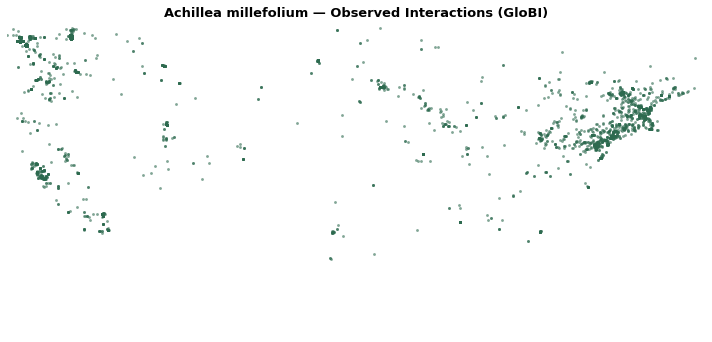

Saved fig1_ground_truth.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')
ax.scatter(
    gt['decimalLongitude'], gt['decimalLatitude'],
    c='#2d6a4f', s=8, alpha=0.6, linewidths=0
)
ax.set_xlim(*CONUS_LON); ax.set_ylim(*CONUS_LAT)
ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Achillea millefolium — Observed Interactions (GloBI)',
             fontsize=13, fontweight='bold', pad=10)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig(OUT + "fig1_ground_truth.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig1_ground_truth.png")

In [5]:
import subprocess
result = subprocess.run(['python', '-c', 'import cartopy; print(cartopy.__version__)'],
                       capture_output=True, text=True)
print(result.stdout or result.stderr)

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'cartopy'



In [6]:
#try to add the CONUS outline
import subprocess
result = subprocess.run(
    ['pip', 'install', 'cartopy', '--break-system-packages'],
    capture_output=True, text=True
)
print(result.stdout[-3000:])
print(result.stderr[-1000:])



Usage:   
  pip install [options] <requirement specifier> [package-index-options] ...
  pip install [options] -r <requirements file> [package-index-options] ...
  pip install [options] [-e] <vcs project url> ...
  pip install [options] [-e] <local project path> ...
  pip install [options] <archive url/path> ...

no such option: --break-system-packages



In [7]:
result = subprocess.run(
    ['pip', 'install', 'cartopy', '--user'],
    capture_output=True, text=True
)
print(result.stdout[-3000:])
print(result.stderr[-1000:])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 69.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 KB 44.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 90.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 92.5 MB/s eta 0:00:00

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.



/home/ariana.l/.local/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/ariana.l/.local/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/ariana.l/.local/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


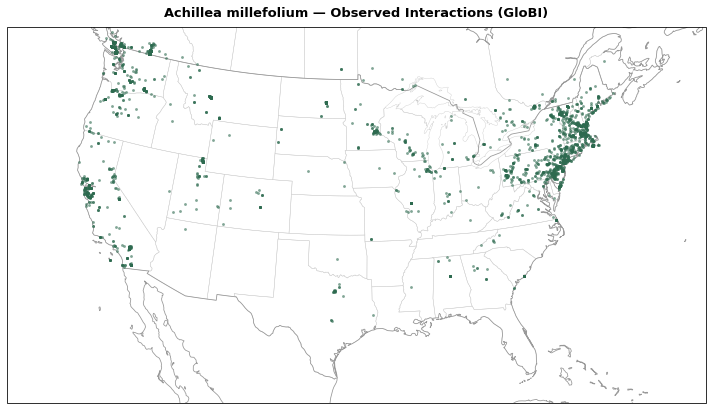

Saved fig1_ground_truth.png


In [8]:
#updated cell 4
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor='white',
    subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
)
ax.set_facecolor('white')
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

# CONUS outline
ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='#cccccc', facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999')

# Ground truth scatter
ax.scatter(
    gt['decimalLongitude'], gt['decimalLatitude'],
    c='#2d6a4f', s=8, alpha=0.6, linewidths=0,
    transform=ccrs.PlateCarree(), zorder=5
)

ax.set_title('Achillea millefolium — Observed Interactions (GloBI)',
             fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig(OUT + "fig1_ground_truth.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig1_ground_truth.png")

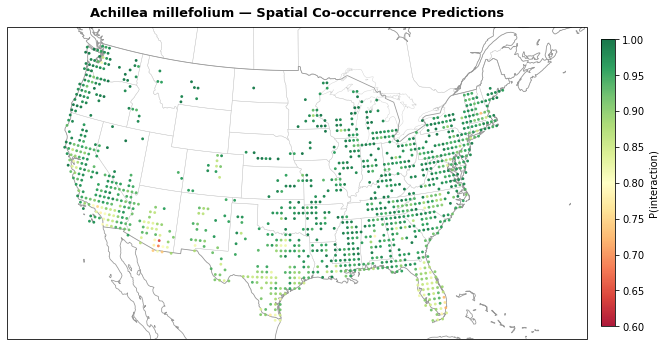

Saved fig2_spatial_cooccurrence.png


In [9]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

a2_data = pred_df[pred_df['week'] == 1]

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor='white',
    subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
)
ax.set_facecolor('white')
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

# CONUS outline
ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='#cccccc', facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999')

# Spatial co-occurrence predictions
sc = ax.scatter(
    a2_data['lon'], a2_data['lat'],
    c=a2_data['pred_a2'], cmap=CMAP_PRED,
    s=8, vmin=0.6, vmax=1.0, alpha=0.9, linewidths=0,
    transform=ccrs.PlateCarree(), zorder=5
)

ax.set_title('Achillea millefolium — Spatial Co-occurrence Predictions',
             fontsize=13, fontweight='bold', pad=10)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('P(interaction)', fontsize=10)

plt.tight_layout()
plt.savefig(OUT + "fig2_spatial_cooccurrence.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig2_spatial_cooccurrence.png")

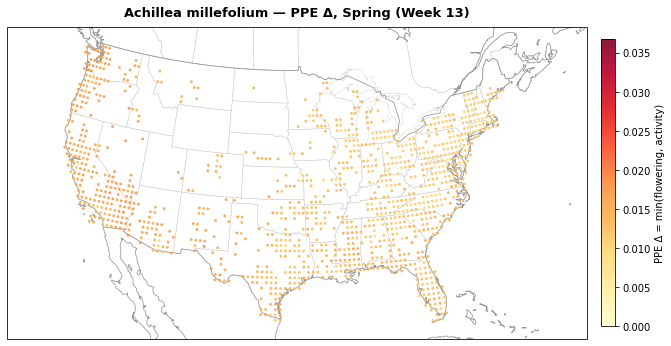

Saved fig3_ppe_delta_spring.png


In [10]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

week_data = delta_df[delta_df['week'] == 13]
vmax_delta = delta_df['delta'].max()

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor='white',
    subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
)
ax.set_facecolor('white')
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='#cccccc', facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999')

sc = ax.scatter(
    week_data['lon'], week_data['lat'],
    c=week_data['delta'], cmap=CMAP_DELTA,
    s=8, vmin=0, vmax=vmax_delta, alpha=0.9, linewidths=0,
    transform=ccrs.PlateCarree(), zorder=5
)

ax.set_title('Achillea millefolium — PPE Δ, Spring (Week 13)',
             fontsize=13, fontweight='bold', pad=10)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('PPE Δ = min(flowering, activity)', fontsize=10)

plt.tight_layout()
plt.savefig(OUT + "fig3_ppe_delta_spring.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig3_ppe_delta_spring.png")

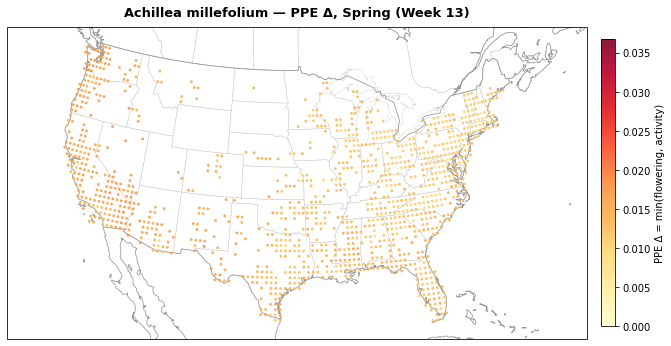

Saved fig3_ppe_delta_spring.png


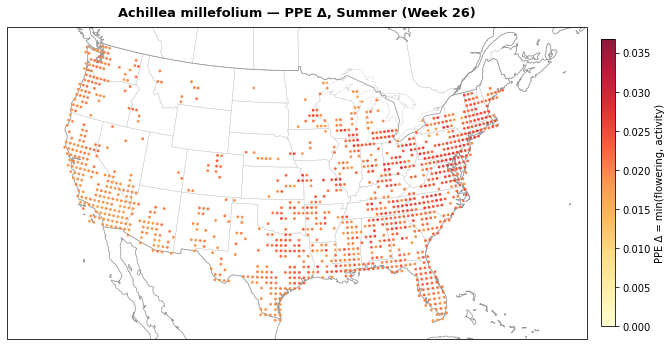

Saved fig4_ppe_delta_summer.png


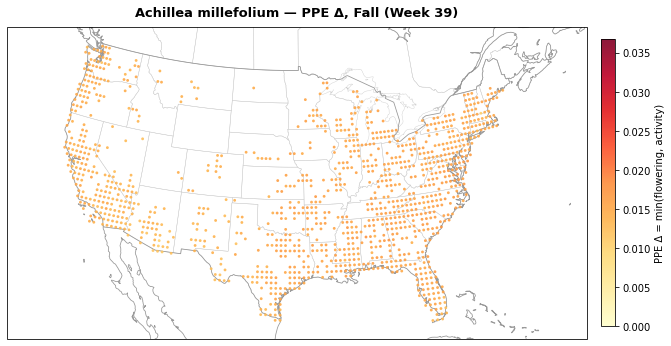

Saved fig5_ppe_delta_fall.png


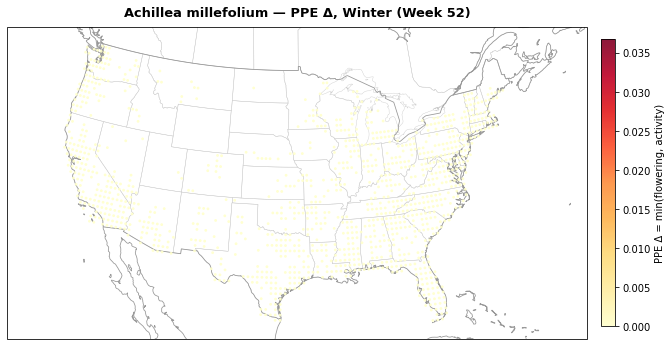

Saved fig6_ppe_delta_winter.png


In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

SEASON_WEEKS = {
    13: ('Spring', 'fig3_ppe_delta_spring.png'),
    26: ('Summer', 'fig4_ppe_delta_summer.png'),
    39: ('Fall',   'fig5_ppe_delta_fall.png'),
    52: ('Winter', 'fig6_ppe_delta_winter.png'),
}
vmax_delta = delta_df['delta'].max()

for week, (season, fname) in SEASON_WEEKS.items():
    week_data = delta_df[delta_df['week'] == week]

    fig, ax = plt.subplots(
        figsize=(10, 6),
        facecolor='white',
        subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
    )
    ax.set_facecolor('white')
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='#cccccc', facecolor='none')
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999')

    sc = ax.scatter(
        week_data['lon'], week_data['lat'],
        c=week_data['delta'], cmap=CMAP_DELTA,
        s=8, vmin=0, vmax=vmax_delta, alpha=0.9, linewidths=0,
        transform=ccrs.PlateCarree(), zorder=5
    )

    ax.set_title(f'Achillea millefolium — PPE Δ, {season} (Week {week})',
                 fontsize=13, fontweight='bold', pad=10)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('PPE Δ = min(flowering, activity)', fontsize=10)

    plt.tight_layout()
    plt.savefig(OUT + fname, dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved {fname}")

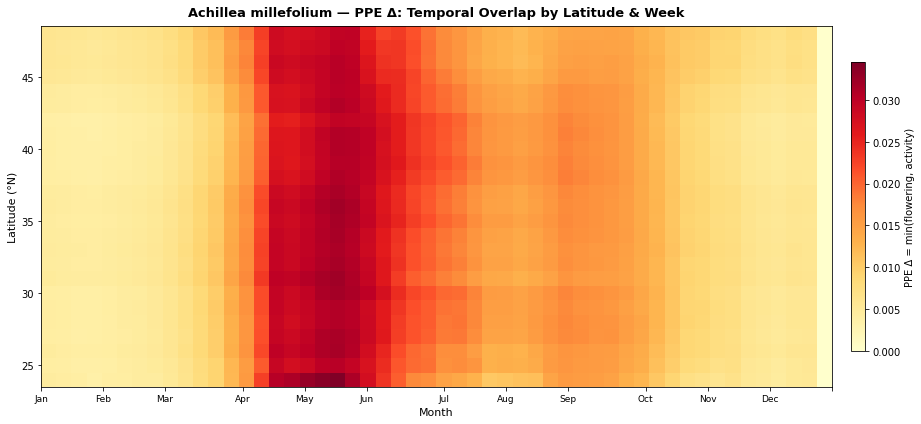

Saved fig7_hovmoller.png


In [12]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

delta_df['lat_band'] = np.floor(delta_df['lat']).astype(int)
hovmoller_delta = (
    delta_df.groupby(['lat_band', 'week'])['delta']
    .mean()
    .unstack(fill_value=np.nan)
)

month_ticks  = [1, 5, 9, 14, 18, 22, 27, 31, 35, 40, 44, 48, 52]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec','']

fig, ax = plt.subplots(figsize=(14, 6), facecolor='white')
ax.set_facecolor('white')

im = ax.imshow(
    hovmoller_delta.sort_index(ascending=False),
    aspect='auto', cmap=CMAP_DELTA,
    vmin=0, vmax=hovmoller_delta.values.max(),
    extent=[1, 52,
            hovmoller_delta.index.min() - 0.5,
            hovmoller_delta.index.max() + 0.5]
)

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Latitude (°N)', fontsize=11)
ax.set_title('Achillea millefolium — PPE Δ: Temporal Overlap by Latitude & Week',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels, fontsize=9)

cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('PPE Δ = min(flowering, activity)', fontsize=10)

plt.tight_layout()
plt.savefig(OUT + "fig7_hovmoller.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig7_hovmoller.png")

/tmp/ipykernel_61783/3405278879.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['pred_a3'] - x['pred_a2']).mean())


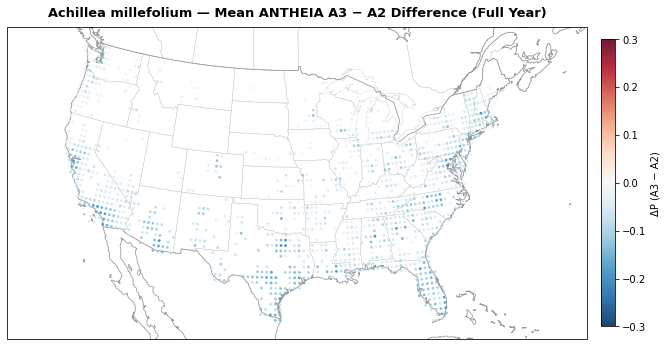

Saved fig8_a3_minus_a2.png


In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

diff_mean = (
    pred_df.groupby(['lat', 'lon'])
    .apply(lambda x: (x['pred_a3'] - x['pred_a2']).mean())
    .reset_index(name='diff_mean')
)

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor='white',
    subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
)
ax.set_facecolor('white')
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='#cccccc', facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999')

sc = ax.scatter(
    diff_mean['lon'], diff_mean['lat'],
    c=diff_mean['diff_mean'], cmap=CMAP_DIFF,
    s=8, vmin=-0.3, vmax=0.3, alpha=0.9, linewidths=0,
    transform=ccrs.PlateCarree(), zorder=5
)

ax.set_title('Achillea millefolium — Mean ANTHEIA A3 − A2 Difference (Full Year)',
             fontsize=13, fontweight='bold', pad=10)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('ΔP (A3 − A2)', fontsize=10)

plt.tight_layout()
plt.savefig(OUT + "fig8_a3_minus_a2.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig8_a3_minus_a2.png")

/tmp/ipykernel_61783/2557213681.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['pred_a3'] - x['pred_a2']).mean())


Color range: -0.1437 to 0.1437


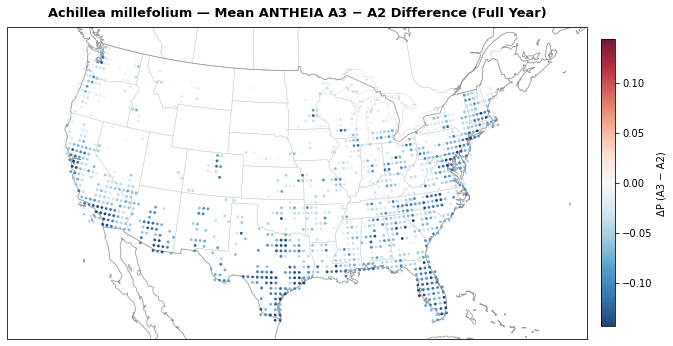

Saved fig8_a3_minus_a2.png


In [14]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

diff_mean = (
    pred_df.groupby(['lat', 'lon'])
    .apply(lambda x: (x['pred_a3'] - x['pred_a2']).mean())
    .reset_index(name='diff_mean')
)

# Use actual data percentiles for better color contrast
vmax = diff_mean['diff_mean'].abs().quantile(0.95)
vmin = -vmax

print(f"Color range: {vmin:.4f} to {vmax:.4f}")

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor='white',
    subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
)
ax.set_facecolor('white')
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='#cccccc', facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999')

sc = ax.scatter(
    diff_mean['lon'], diff_mean['lat'],
    c=diff_mean['diff_mean'], cmap=CMAP_DIFF,
    s=8, vmin=vmin, vmax=vmax, alpha=0.9, linewidths=0,
    transform=ccrs.PlateCarree(), zorder=5
)

ax.set_title('Achillea millefolium — Mean ANTHEIA A3 − A2 Difference (Full Year)',
             fontsize=13, fontweight='bold', pad=10)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('ΔP (A3 − A2)', fontsize=10)

plt.tight_layout()
plt.savefig(OUT + "fig8_a3_minus_a2.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig8_a3_minus_a2.png")

Spring color range: -0.1449 to 0.1449


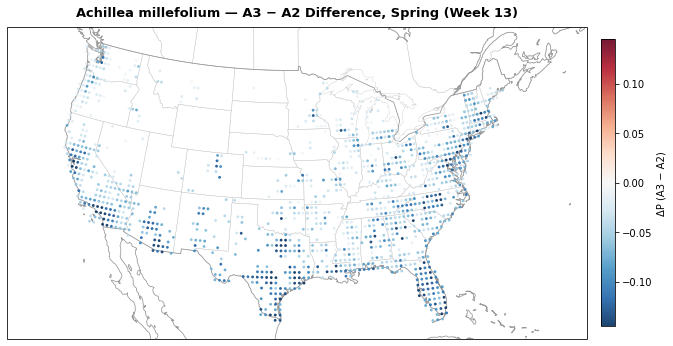

Saved fig9_diff_spring.png
Summer color range: -0.1392 to 0.1392


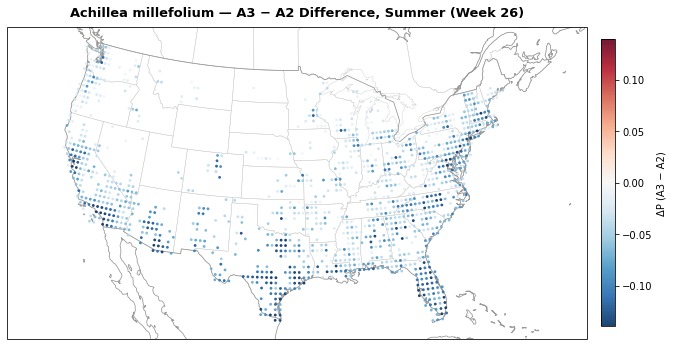

Saved fig10_diff_summer.png
Fall color range: -0.1429 to 0.1429


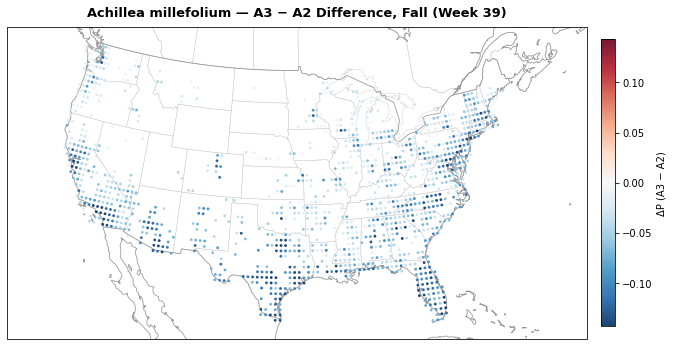

Saved fig11_diff_fall.png
Winter color range: -0.1480 to 0.1480


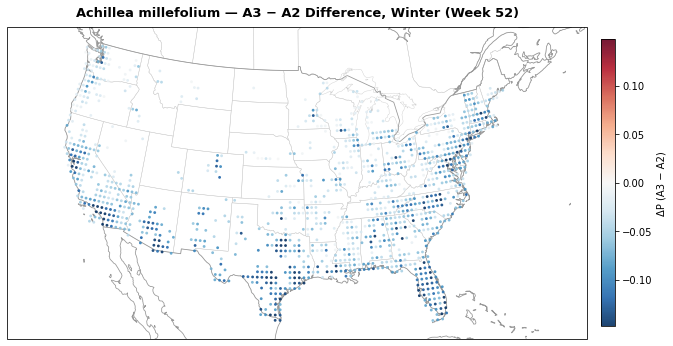

Saved fig12_diff_winter.png


In [15]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

SEASON_WEEKS = {
    13: ('Spring', 'fig9_diff_spring.png'),
    26: ('Summer', 'fig10_diff_summer.png'),
    39: ('Fall',   'fig11_diff_fall.png'),
    52: ('Winter', 'fig12_diff_winter.png'),
}

for week, (season, fname) in SEASON_WEEKS.items():
    week_data = pred_df[pred_df['week'] == week].copy()
    week_data['diff'] = week_data['pred_a3'] - week_data['pred_a2']

    vmax = week_data['diff'].abs().quantile(0.95)
    vmin = -vmax
    print(f"{season} color range: {vmin:.4f} to {vmax:.4f}")

    fig, ax = plt.subplots(
        figsize=(10, 6),
        facecolor='white',
        subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
    )
    ax.set_facecolor('white')
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='#cccccc', facecolor='none')
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999')

    sc = ax.scatter(
        week_data['lon'], week_data['lat'],
        c=week_data['diff'], cmap=CMAP_DIFF,
        s=8, vmin=vmin, vmax=vmax, alpha=0.9, linewidths=0,
        transform=ccrs.PlateCarree(), zorder=5
    )

    ax.set_title(f'Achillea millefolium — A3 − A2 Difference, {season} (Week {week})',
                 fontsize=13, fontweight='bold', pad=10)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('ΔP (A3 − A2)', fontsize=10)

    plt.tight_layout()
    plt.savefig(OUT + fname, dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved {fname}")

Spring color range: -0.1135 to 0.1135


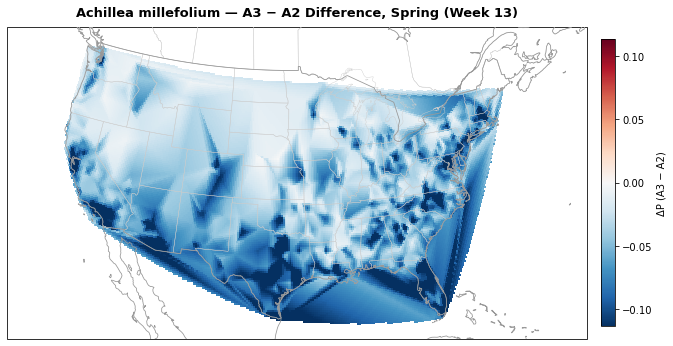

Saved fig9_diff_spring.png
Summer color range: -0.1109 to 0.1109


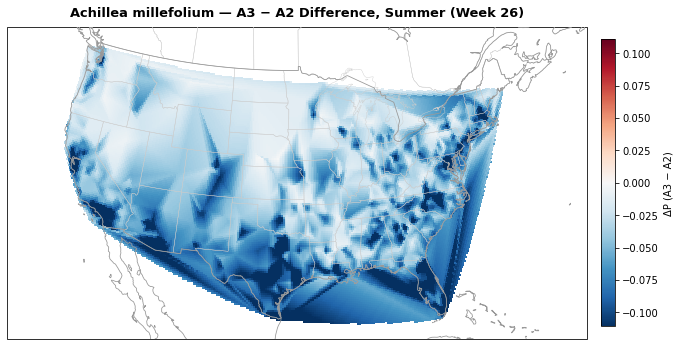

Saved fig10_diff_summer.png
Fall color range: -0.1129 to 0.1129


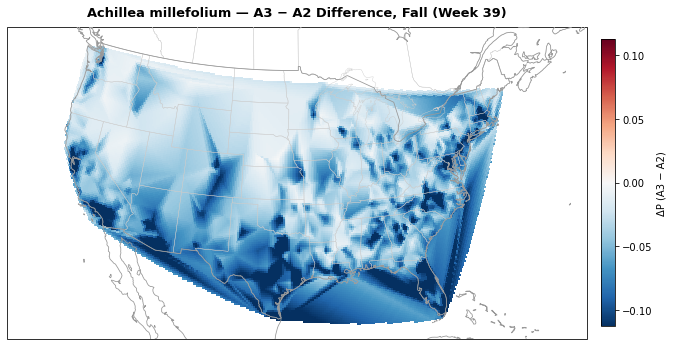

Saved fig11_diff_fall.png
Winter color range: -0.1159 to 0.1159


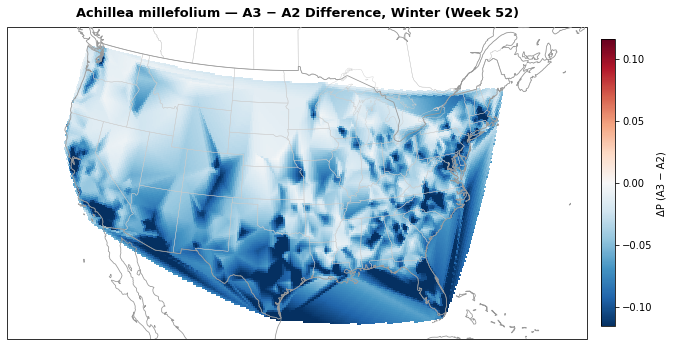

Saved fig12_diff_winter.png


In [16]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from scipy.interpolate import griddata

SEASON_WEEKS = {
    13: ('Spring', 'fig9_diff_spring.png'),
    26: ('Summer', 'fig10_diff_summer.png'),
    39: ('Fall',   'fig11_diff_fall.png'),
    52: ('Winter', 'fig12_diff_winter.png'),
}

# Regular grid for interpolation
lon_grid = np.linspace(-125, -66, 300)
lat_grid = np.linspace(24, 50, 150)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

for week, (season, fname) in SEASON_WEEKS.items():
    week_data = pred_df[pred_df['week'] == week].dropna(subset=['pred_a3', 'pred_a2']).copy()
    week_data['diff'] = week_data['pred_a3'] - week_data['pred_a2']

    # Interpolate scattered points onto regular grid
    diff_grid = griddata(
        points=(week_data['lon'].values, week_data['lat'].values),
        values=week_data['diff'].values,
        xi=(lon_mesh, lat_mesh),
        method='linear'
    )

    vmax = np.nanpercentile(np.abs(diff_grid), 95)
    vmin = -vmax
    print(f"{season} color range: {vmin:.4f} to {vmax:.4f}")

    fig, ax = plt.subplots(
        figsize=(10, 6),
        facecolor='white',
        subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
    )
    ax.set_facecolor('white')
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

    im = ax.pcolormesh(
        lon_mesh, lat_mesh, diff_grid,
        cmap=CMAP_DIFF, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(), zorder=3
    )

    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='#cccccc', facecolor='none', zorder=4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none', zorder=4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999', zorder=4)

    ax.set_title(f'Achillea millefolium — A3 − A2 Difference, {season} (Week {week})',
                 fontsize=13, fontweight='bold', pad=10)

    cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('ΔP (A3 − A2)', fontsize=10)

    plt.tight_layout()
    plt.savefig(OUT + fname, dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved {fname}")

Shared color range: -0.1426 to 0.1426


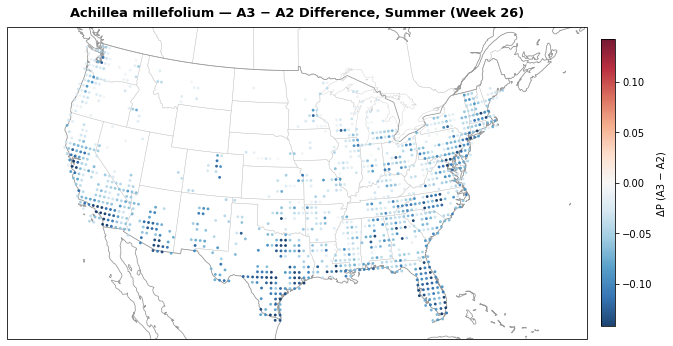

Saved fig10_diff_summer.png


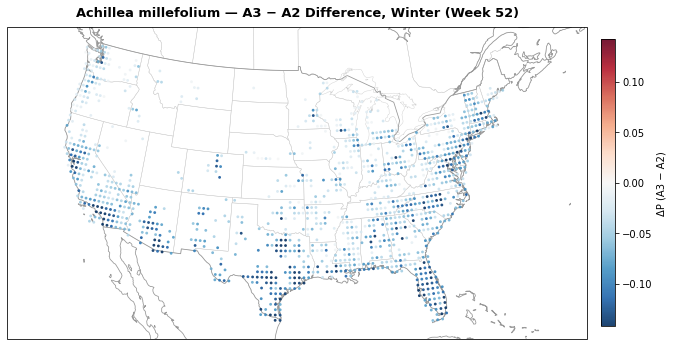

Saved fig12_diff_winter.png


In [20]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

SEASON_WEEKS = {
    26: ('Summer', 'fig10_diff_summer.png'),
    52: ('Winter', 'fig12_diff_winter.png'),
}

# Compute global vmax across both seasons for fair comparison
all_diffs = []
for week in SEASON_WEEKS.keys():
    week_data = pred_df[pred_df['week'] == week].dropna(subset=['pred_a3', 'pred_a2']).copy()
    week_data['diff'] = week_data['pred_a3'] - week_data['pred_a2']
    all_diffs.append(week_data['diff'])

global_vmax = pd.concat(all_diffs).abs().quantile(0.95)
global_vmin = -global_vmax
print(f"Shared color range: {global_vmin:.4f} to {global_vmax:.4f}")

for week, (season, fname) in SEASON_WEEKS.items():
    week_data = pred_df[pred_df['week'] == week].dropna(subset=['pred_a3', 'pred_a2']).copy()
    week_data['diff'] = week_data['pred_a3'] - week_data['pred_a2']

    fig, ax = plt.subplots(
        figsize=(10, 6),
        facecolor='white',
        subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
    )
    ax.set_facecolor('white')
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='#cccccc', facecolor='none')
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999')

    sc = ax.scatter(
        week_data['lon'], week_data['lat'],
        c=week_data['diff'], cmap=CMAP_DIFF,
        s=8, vmin=global_vmin, vmax=global_vmax, alpha=0.9, linewidths=0,
        transform=ccrs.PlateCarree(), zorder=5
    )

    ax.set_title(f'Achillea millefolium — A3 − A2 Difference, {season} (Week {week})',
                 fontsize=13, fontweight='bold', pad=10)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('ΔP (A3 − A2)', fontsize=10)

    plt.tight_layout()
    plt.savefig(OUT + fname, dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved {fname}")

In [18]:
for week, season in [(26, 'Summer'), (52, 'Winter')]:
    week_data = pred_df[pred_df['week'] == week].dropna(subset=['pred_a3', 'pred_a2']).copy()
    week_data['diff'] = week_data['pred_a3'] - week_data['pred_a2']
    print(f"{season} (Week {week}):")
    print(f"  mean:   {week_data['diff'].mean():.4f}")
    print(f"  std:    {week_data['diff'].std():.4f}")
    print(f"  min:    {week_data['diff'].min():.4f}")
    print(f"  max:    {week_data['diff'].max():.4f}")
    print(f"  95th percentile abs: {week_data['diff'].abs().quantile(0.95):.4f}")
    print()

Summer (Week 26):
  mean:   -0.0617
  std:    0.0404
  min:    -0.1962
  max:    -0.0002
  95th percentile abs: 0.1392

Winter (Week 52):
  mean:   -0.0652
  std:    0.0423
  min:    -0.2063
  max:    -0.0003
  95th percentile abs: 0.1480



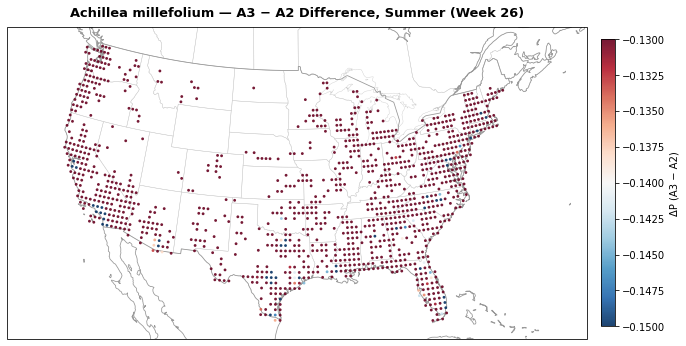

Saved fig10_diff_summer.png


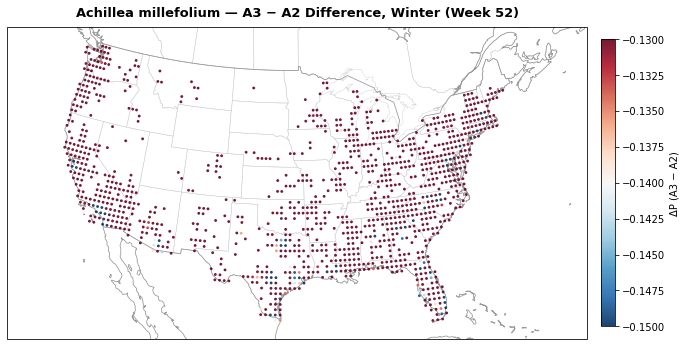

Saved fig12_diff_winter.png


In [19]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

SEASON_WEEKS = {
    26: ('Summer', 'fig10_diff_summer.png'),
    52: ('Winter', 'fig12_diff_winter.png'),
}

global_vmin = -0.15
global_vmax = -0.13

for week, (season, fname) in SEASON_WEEKS.items():
    week_data = pred_df[pred_df['week'] == week].dropna(subset=['pred_a3', 'pred_a2']).copy()
    week_data['diff'] = week_data['pred_a3'] - week_data['pred_a2']

    fig, ax = plt.subplots(
        figsize=(10, 6),
        facecolor='white',
        subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
    )
    ax.set_facecolor('white')
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='#cccccc', facecolor='none')
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999')

    sc = ax.scatter(
        week_data['lon'], week_data['lat'],
        c=week_data['diff'], cmap=CMAP_DIFF,
        s=8, vmin=global_vmin, vmax=global_vmax, alpha=0.9, linewidths=0,
        transform=ccrs.PlateCarree(), zorder=5
    )

    ax.set_title(f'Achillea millefolium — A3 − A2 Difference, {season} (Week {week})',
                 fontsize=13, fontweight='bold', pad=10)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('ΔP (A3 − A2)', fontsize=10)

    plt.tight_layout()
    plt.savefig(OUT + fname, dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved {fname}")

In [21]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Find peak flowering week per bin for Achillea
# achillea df has columns: centroid_lat, centroid_lon, week, norm
achillea_peak = (
    achillea.loc[achillea.groupby(['centroid_lat', 'centroid_lon'])['norm'].idxmax()]
    [['centroid_lat', 'centroid_lon', 'week']]
    .reset_index(drop=True)
)

print(f"Grid cells: {len(achillea_peak):,}")
print(f"Peak week range: {achillea_peak['week'].min()} to {achillea_peak['week'].max()}")

# Week -> month labels for colorbar
month_ticks = [1, 5, 9, 14, 18, 22, 27, 31, 35, 40, 44, 48, 52]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec','']

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor='white',
    subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
)
ax.set_facecolor('white')
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='#cccccc', facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999')

sc = ax.scatter(
    achillea_peak['centroid_lon'], achillea_peak['centroid_lat'],
    c=achillea_peak['week'], cmap='RdYlBu_r',
    s=8, vmin=1, vmax=52, alpha=0.9, linewidths=0,
    transform=ccrs.PlateCarree(), zorder=5
)

ax.set_title('Achillea millefolium — Peak Flowering Week across CONUS',
             fontsize=13, fontweight='bold', pad=10)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Peak Flowering Week', fontsize=10)
cbar.set_ticks(month_ticks)
cbar.set_ticklabels(month_labels)

plt.tight_layout()
plt.savefig(OUT + "fig_peak_flowering_week.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig_peak_flowering_week.png")

NameError: name 'achillea' is not defined

In [22]:
import glob

files = sorted(glob.glob("/scratch/ariana.l/ppe-outputs/opportunity_surface/part_*.parquet"))
achillea_data = []
for f in files:
    df = pd.read_parquet(f)
    subset = df[df['species'] == 'Achillea millefolium']
    if len(subset) > 0:
        achillea_data.append(subset)
achillea = pd.concat(achillea_data, ignore_index=True)
print(f"achillea: {achillea.shape}")
print(achillea.columns.tolist())

achillea: (98817, 9)
['species', 'species_id', 'cell_idx', 'centroid_lat', 'centroid_lon', 'week', 'doy', 'p_flowering', 'norm']


Grid cells: 3,335
Peak week range: 2 to 50


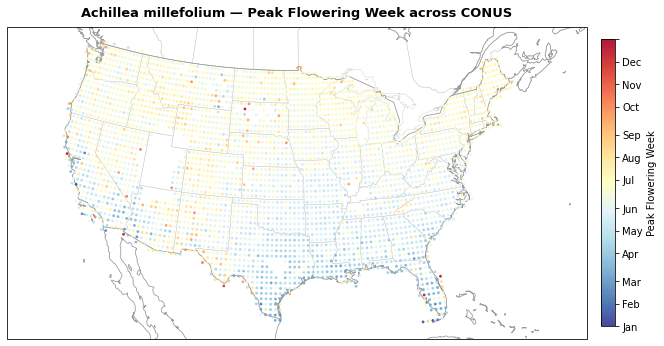

Saved fig_peak_flowering_week.png


In [23]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Find peak flowering week per bin for Achillea
# achillea df has columns: centroid_lat, centroid_lon, week, norm
achillea_peak = (
    achillea.loc[achillea.groupby(['centroid_lat', 'centroid_lon'])['norm'].idxmax()]
    [['centroid_lat', 'centroid_lon', 'week']]
    .reset_index(drop=True)
)

print(f"Grid cells: {len(achillea_peak):,}")
print(f"Peak week range: {achillea_peak['week'].min()} to {achillea_peak['week'].max()}")

# Week -> month labels for colorbar
month_ticks = [1, 5, 9, 14, 18, 22, 27, 31, 35, 40, 44, 48, 52]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec','']

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor='white',
    subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
)
ax.set_facecolor('white')
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='#cccccc', facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999')

sc = ax.scatter(
    achillea_peak['centroid_lon'], achillea_peak['centroid_lat'],
    c=achillea_peak['week'], cmap='RdYlBu_r',
    s=8, vmin=1, vmax=52, alpha=0.9, linewidths=0,
    transform=ccrs.PlateCarree(), zorder=5
)

ax.set_title('Achillea millefolium — Peak Flowering Week across CONUS',
             fontsize=13, fontweight='bold', pad=10)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Peak Flowering Week', fontsize=10)
cbar.set_ticks(month_ticks)
cbar.set_ticklabels(month_labels)

plt.tight_layout()
plt.savefig(OUT + "fig_peak_flowering_week.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig_peak_flowering_week.png")

In [24]:
print(f"Peak week range: {achillea_peak['week'].min()} to {achillea_peak['week'].max()}")
print(achillea_peak['week'].value_counts().sort_index())

Peak week range: 2 to 50
week
2       1
3       2
7       4
8       3
9       4
10     11
11     22
12     25
13     17
14     40
15     53
16     85
17     53
18     96
19    149
20    241
21    195
22    238
23    296
24    345
25    339
26    315
27    225
28    165
29    126
30    104
31     63
32     32
33     17
34     20
35      8
36      8
37      7
38      8
39      5
40      3
41      3
42      1
46      1
50      5
Name: count, dtype: int64


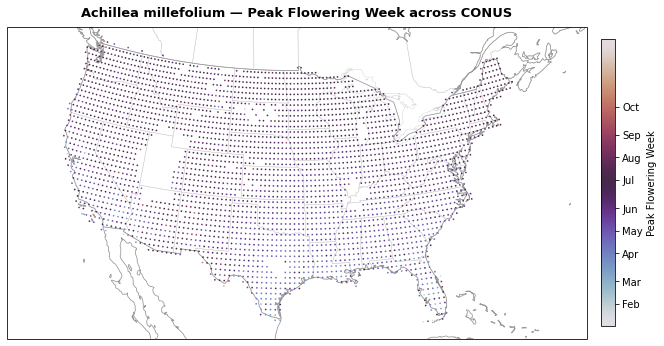

Saved fig_peak_flowering_week_cyclic.png


In [26]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

month_ticks  = [5, 9, 14, 18, 22, 27, 31, 35, 40]
month_labels = ['Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct']

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor='white',
    subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
)
ax.set_facecolor('white')
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='#cccccc', facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999')

sc = ax.scatter(
    achillea_peak['centroid_lon'], achillea_peak['centroid_lat'],
    c=achillea_peak['week'], cmap='twilight',
    s=3, vmin=1, vmax=52, alpha=0.9, linewidths=0,
    transform=ccrs.PlateCarree(), zorder=5
)

ax.set_title('Achillea millefolium — Peak Flowering Week across CONUS',
             fontsize=13, fontweight='bold', pad=10)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Peak Flowering Week', fontsize=10)
cbar.set_ticks(month_ticks)
cbar.set_ticklabels(month_labels)

plt.tight_layout()
plt.savefig(OUT + "fig_peak_flowering_week_cyclic.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig_peak_flowering_week_cyclic.png")

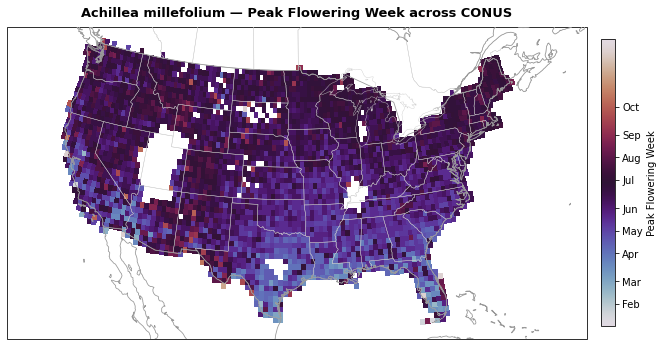

Saved fig_peak_flowering_week_grid.png


In [27]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Pivot to regular grid
peak_grid = achillea_peak.pivot(index='centroid_lat', columns='centroid_lon', values='week')

lats = peak_grid.index.values
lons = peak_grid.columns.values
lon_mesh, lat_mesh = np.meshgrid(lons, lats)

month_ticks  = [5, 9, 14, 18, 22, 27, 31, 35, 40]
month_labels = ['Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct']

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor='white',
    subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
)
ax.set_facecolor('white')
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon_mesh, lat_mesh, peak_grid.values,
    cmap='twilight', vmin=1, vmax=52,
    transform=ccrs.PlateCarree(), zorder=3
)

ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='#cccccc', facecolor='none', zorder=4)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none', zorder=4)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999', zorder=4)

ax.set_title('Achillea millefolium — Peak Flowering Week across CONUS',
             fontsize=13, fontweight='bold', pad=10)

cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Peak Flowering Week', fontsize=10)
cbar.set_ticks(month_ticks)
cbar.set_ticklabels(month_labels)

plt.tight_layout()
plt.savefig(OUT + "fig_peak_flowering_week_grid.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig_peak_flowering_week_grid.png")

/home/ariana.l/.local/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


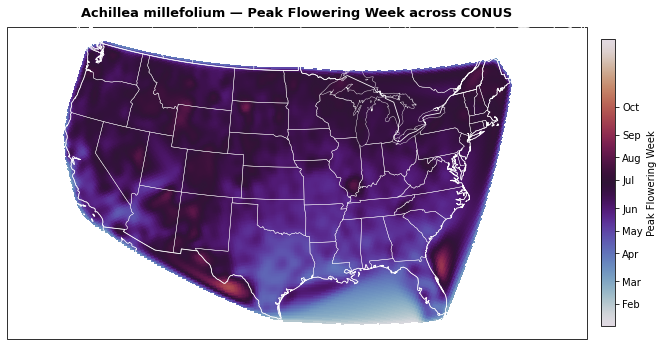

Saved fig_peak_flowering_week_smooth.png


In [28]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata

# First interpolate to a full regular grid, then smooth
lon_grid = np.linspace(-125, -66, 400)
lat_grid = np.linspace(24, 50, 200)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Interpolate scattered points to regular grid
peak_interp = griddata(
    points=(achillea_peak['centroid_lon'].values, achillea_peak['centroid_lat'].values),
    values=achillea_peak['week'].values,
    xi=(lon_mesh, lat_mesh),
    method='linear'
)

# Apply Gaussian smoothing to fill gaps and smooth edges
peak_smooth = gaussian_filter(np.nan_to_num(peak_interp, nan=0), sigma=3)

# Mask areas far from any data point (to avoid coloring ocean/Canada)
coverage = griddata(
    points=(achillea_peak['centroid_lon'].values, achillea_peak['centroid_lat'].values),
    values=np.ones(len(achillea_peak)),
    xi=(lon_mesh, lat_mesh),
    method='linear'
)
peak_smooth = np.where(np.isnan(coverage), np.nan, peak_smooth)

month_ticks  = [5, 9, 14, 18, 22, 27, 31, 35, 40]
month_labels = ['Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct']

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor='white',
    subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
)
ax.set_facecolor('white')
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon_mesh, lat_mesh, peak_smooth,
    cmap='twilight', vmin=1, vmax=52,
    transform=ccrs.PlateCarree(), zorder=3
)

ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='white', facecolor='none', zorder=4)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='white', facecolor='none', zorder=4)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='white', zorder=4)
ax.add_feature(cfeature.LAND, facecolor='none', zorder=2)

ax.set_title('Achillea millefolium — Peak Flowering Week across CONUS',
             fontsize=13, fontweight='bold', pad=10)

cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Peak Flowering Week', fontsize=10)
cbar.set_ticks(month_ticks)
cbar.set_ticklabels(month_labels)

plt.tight_layout()
plt.savefig(OUT + "fig_peak_flowering_week_smooth.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig_peak_flowering_week_smooth.png")

/home/ariana.l/.local/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


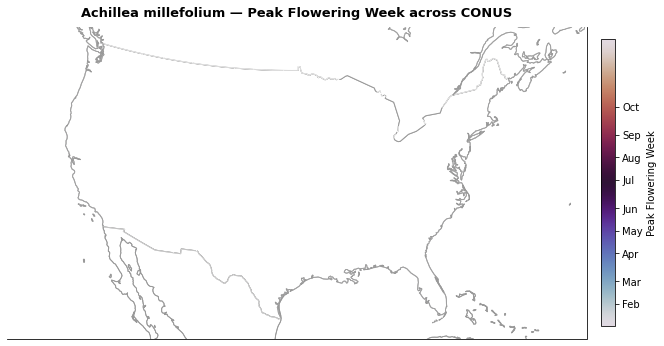

Saved fig_peak_flowering_week_smooth.png


In [30]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import numpy as np
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
from matplotlib.patches import PathPatch

lon_grid = np.linspace(-125, -66, 400)
lat_grid = np.linspace(24, 50, 200)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

peak_interp = griddata(
    points=(achillea_peak['centroid_lon'].values, achillea_peak['centroid_lat'].values),
    values=achillea_peak['week'].values,
    xi=(lon_mesh, lat_mesh),
    method='linear'
)

peak_smooth = gaussian_filter(np.nan_to_num(peak_interp, nan=0), sigma=3)

coverage = griddata(
    points=(achillea_peak['centroid_lon'].values, achillea_peak['centroid_lat'].values),
    values=np.ones(len(achillea_peak)),
    xi=(lon_mesh, lat_mesh),
    method='linear'
)
peak_smooth = np.where(np.isnan(coverage), np.nan, peak_smooth)

month_ticks  = [5, 9, 14, 18, 22, 27, 31, 35, 40]
month_labels = ['Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct']

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor='white',
    subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
)
ax.set_facecolor('white')
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon_mesh, lat_mesh, peak_smooth,
    cmap='twilight', vmin=1, vmax=52,
    transform=ccrs.PlateCarree(), zorder=3
)

# Cover non-CONUS areas with white
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=4)
ax.add_feature(cfeature.LAKES, facecolor='white', zorder=4)

# Cover Canada and Mexico explicitly
non_us = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_countries',
    scale='50m',
    facecolor='white',
    edgecolor='#999999'
)
ax.add_feature(non_us, zorder=5)

# Re-draw US on top to restore CONUS color
us_states = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lakes',
    scale='50m',
    facecolor='none',
    edgecolor='white',
    linewidth=0.4
)
ax.add_feature(us_states, zorder=6)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999', zorder=7)

ax.set_title('Achillea millefolium — Peak Flowering Week across CONUS',
             fontsize=13, fontweight='bold', pad=10)

cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Peak Flowering Week', fontsize=10)
cbar.set_ticks(month_ticks)
cbar.set_ticklabels(month_labels)

plt.tight_layout()
plt.savefig(OUT + "fig_peak_flowering_week_smooth.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig_peak_flowering_week_smooth.png")

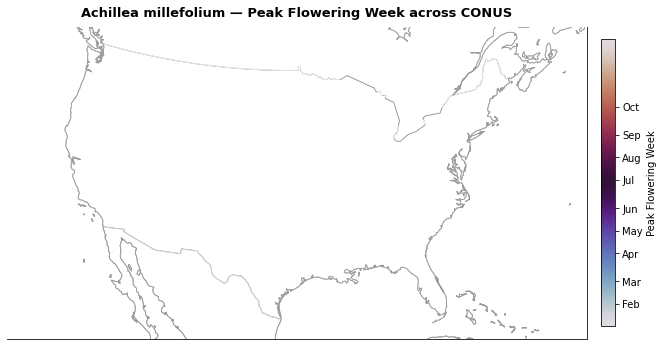

Saved fig_peak_flowering_week_smooth.png


In [31]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata

lon_grid = np.linspace(-125, -66, 400)
lat_grid = np.linspace(24, 50, 200)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

peak_interp = griddata(
    points=(achillea_peak['centroid_lon'].values, achillea_peak['centroid_lat'].values),
    values=achillea_peak['week'].values,
    xi=(lon_mesh, lat_mesh),
    method='linear'
)
peak_smooth = gaussian_filter(np.nan_to_num(peak_interp, nan=0), sigma=3)
coverage = griddata(
    points=(achillea_peak['centroid_lon'].values, achillea_peak['centroid_lat'].values),
    values=np.ones(len(achillea_peak)),
    xi=(lon_mesh, lat_mesh),
    method='linear'
)
peak_smooth = np.where(np.isnan(coverage), np.nan, peak_smooth)

month_ticks  = [5, 9, 14, 18, 22, 27, 31, 35, 40]
month_labels = ['Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct']

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor='white',
    subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
)
ax.set_facecolor('white')
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

# Step 1: White background for all countries (covers Canada/Mexico)
non_us = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_0_countries',
    scale='50m', facecolor='white', edgecolor='none'
)
ax.add_feature(non_us, zorder=2)

# Step 2: Draw pcolormesh on top
im = ax.pcolormesh(
    lon_mesh, lat_mesh, peak_smooth,
    cmap='twilight', vmin=1, vmax=52,
    transform=ccrs.PlateCarree(), zorder=3
)

# Step 3: Cover Canada and Mexico again on top of pcolormesh
ax.add_feature(cfeature.NaturalEarthFeature(
    category='cultural', name='admin_0_countries',
    scale='50m', facecolor='white', edgecolor='none'
), zorder=4)

# Step 4: Cut a hole for the US by clipping with US shapefile
import cartopy.io.shapereader as shpreader
from matplotlib.patches import PathPatch
from matplotlib.path import Path
import shapely.ops as ops
from shapely.geometry import box
import shapefile

# Use NaturalEarth US boundary to clip
us = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_0_boundary_lines_land',
    scale='50m', facecolor='none', edgecolor='none'
)

# Simpler: just re-draw pcolormesh clipped to US extent
# Cover ocean and non-US with white
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=5)
ax.add_feature(cfeature.LAKES, facecolor='white', zorder=5)

# Border countries white fill
ax.add_feature(cfeature.NaturalEarthFeature(
    category='cultural', name='admin_0_countries',
    scale='50m', facecolor='white', edgecolor='#999999',
    linewidth=0.8
), zorder=6)

# Re-draw pcolormesh clipped only to US — use set_clip_path approach
# Draw US states outline
us_states = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lakes',
    scale='50m', facecolor='none', edgecolor='white', linewidth=0.4
)
ax.add_feature(us_states, zorder=7)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999', zorder=8)

ax.set_title('Achillea millefolium — Peak Flowering Week across CONUS',
             fontsize=13, fontweight='bold', pad=10)

cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Peak Flowering Week', fontsize=10)
cbar.set_ticks(month_ticks)
cbar.set_ticklabels(month_labels)

plt.tight_layout()
plt.savefig(OUT + "fig_peak_flowering_week_smooth.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig_peak_flowering_week_smooth.png")

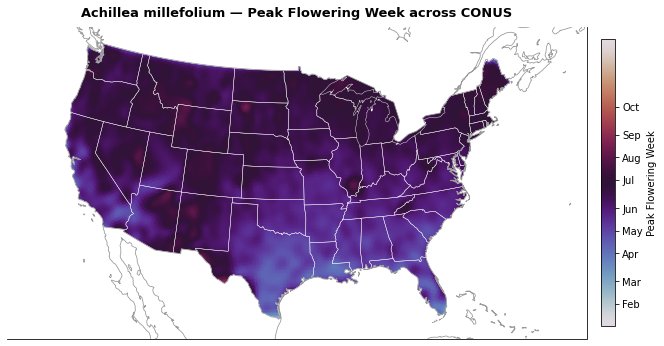

Saved fig_peak_flowering_week_smooth.png


In [32]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import numpy as np
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
import shapely.ops as ops
from shapely.geometry import box, MultiPolygon
import matplotlib.pyplot as plt

# --- Build smoothed grid ---
lon_grid = np.linspace(-125, -66, 400)
lat_grid = np.linspace(24, 50, 200)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

peak_interp = griddata(
    points=(achillea_peak['centroid_lon'].values, achillea_peak['centroid_lat'].values),
    values=achillea_peak['week'].values,
    xi=(lon_mesh, lat_mesh),
    method='linear'
)
peak_smooth = gaussian_filter(np.nan_to_num(peak_interp, nan=0), sigma=3)
coverage = griddata(
    points=(achillea_peak['centroid_lon'].values, achillea_peak['centroid_lat'].values),
    values=np.ones(len(achillea_peak)),
    xi=(lon_mesh, lat_mesh),
    method='linear'
)
peak_smooth = np.where(np.isnan(coverage), np.nan, peak_smooth)

# --- Get US boundary as a single shapely polygon ---
shpfilename = shpreader.natural_earth(
    resolution='50m', category='cultural', name='admin_0_countries'
)
reader = shpreader.Reader(shpfilename)
us_geom = [rec.geometry for rec in reader.records()
           if rec.attributes['NAME'] == 'United States of America'][0]

month_ticks  = [5, 9, 14, 18, 22, 27, 31, 35, 40]
month_labels = ['Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct']

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor='white',
    subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
)
ax.set_facecolor('white')
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

# Draw pcolormesh
im = ax.pcolormesh(
    lon_mesh, lat_mesh, peak_smooth,
    cmap='twilight', vmin=1, vmax=52,
    transform=ccrs.PlateCarree(), zorder=3
)

# Clip to US using add_geometries mask
# Draw white everywhere outside US
from matplotlib.patches import PathPatch
from matplotlib.path import Path
import cartopy.mpl.patch as cpatch

# Invert: draw white over everything, then cut out US shape
world_box = box(-180, -90, 180, 90)
outside_us = world_box.difference(us_geom)

ax.add_geometries(
    [outside_us], crs=ccrs.PlateCarree(),
    facecolor='white', edgecolor='none', zorder=4
)

# State borders and coastline on top
ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='white', facecolor='none', zorder=5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999', zorder=5)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none', zorder=5)

ax.set_title('Achillea millefolium — Peak Flowering Week across CONUS',
             fontsize=13, fontweight='bold', pad=10)

cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Peak Flowering Week', fontsize=10)
cbar.set_ticks(month_ticks)
cbar.set_ticklabels(month_labels)

plt.tight_layout()
plt.savefig(OUT + "fig_peak_flowering_week_smooth.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig_peak_flowering_week_smooth.png")